# Data Quality Assessment & Preprocessing
Dataset: steam data

Course: ARTI406 - Machine Learning

In [1]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [3]:
# Load Dataset
df = pd.read_excel(r"C:\Users\8joon\Downloads\steam_data.xlsx")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,url,name,categories,img_url,user_reviews,all_reviews,date,developer,publisher,price,pegi,pegi_url,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,https://store.steampowered.com/app/945360/Amon...,Among Us,Online PvPLAN PvPOnline Co-opLAN Co-opCross-Pl...,https://steamcdn-a.akamaihd.net/steam/apps/945...,"Overwhelmingly Positive(151,281)- 96% of the 1...","Overwhelmingly Positive(224,878)- 95% of the 2...","Nov 16, 2018",Innersloth,Innersloth,Buy Among Us$4.99Add to Cart,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://store.steampowered.com/app/730/Counter...,Counter-Strike: Global Offensive,Steam AchievementsFull controller supportSteam...,https://steamcdn-a.akamaihd.net/steam/apps/730...,"Very Positive(90,780)- 88% of the 90,780 user ...","Very Positive(4,843,904)- 87% of the 4,843,904...","Aug 21, 2012","Valve, Hidden Path Entertainment",Valve,Play Counter-Strike: Global OffensiveFree to P...,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://store.steampowered.com/app/1097150/Fal...,Fall Guys: Ultimate Knockout,MMOOnline PvPOnline Co-opSteam AchievementsFul...,https://steamcdn-a.akamaihd.net/steam/apps/109...,"Very Positive(32,436)- 84% of the 32,436 user ...","Very Positive(223,706)- 80% of the 223,706 use...","Aug 3, 2020",Mediatonic,Devolver Digital,Buy Fall Guys$19.99Add to Cart,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://store.steampowered.com/app/1158310/Cru...,Crusader Kings III,Single-playerOnline PvPSteam AchievementsSteam...,https://steamcdn-a.akamaihd.net/steam/apps/115...,"Very Positive(5,359)- 91% of the 5,359 user re...","Very Positive(18,951)- 92% of the 18,951 user ...","Sep 1, 2020",Paradox Development Studio,Paradox Interactive,Buy Crusader Kings III$49.99Add to Cart,BloodLanguagePartial NuditySexual ThemesUse of...,https://steamstore-a.akamaihd.net/public/share...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://store.steampowered.com/app/1085660/Des...,Destiny 2,Single-playerOnline PvPOnline Co-opSteam Achie...,https://steamcdn-a.akamaihd.net/steam/apps/108...,"Very Positive(9,147)- 87% of the 9,147 user re...","Very Positive(284,689)- 86% of the 284,689 use...","Oct 1, 2019",Bungie,Bungie,Play Destiny 2Free To PlayPlay Game,Blood Language Violence,https://steamstore-a.akamaihd.net/public/share...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81042,https://store.steampowered.com/app/597700/OVIV...,OVIVO,Single-playerSteam AchievementsSteam Trading C...,https://steamcdn-a.akamaihd.net/steam/apps/597...,Very Positive(304)- 89% of the 304 user review...,2017-05-12 00:00:00,2017-05-12 00:00:00,IzHard,-,Buy OVIVONT$ 102Add to Cart,NaN,https://steamstore-a.akamaihd.net/public/share...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81043,https://store.steampowered.com/bundle/2961/Ste...,-,-,-,-,-,-,-,-,Buy Steam: Rails to Riches - All Map Expansion...,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81044,https://store.steampowered.com/bundle/3123/Det...,-,-,-,-,-,-,-,-,Buy Detective Hank and the Golden Sneeze - Gam...,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81045,https://store.steampowered.com/bundle/3175/Fea...,-,-,-,-,-,-,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Task 1: Identify data quality issues

Check Missing Values

In [4]:
# Check all values
print(df.isna())

         url   name  categories  img_url  user_reviews  all_reviews   date  \
0      False  False       False    False         False        False  False   
1      False  False       False    False         False        False  False   
2      False  False       False    False         False        False  False   
3      False  False       False    False         False        False  False   
4      False  False       False    False         False        False  False   
...      ...    ...         ...      ...           ...          ...    ...   
81043  False  False       False    False         False        False  False   
81044  False  False       False    False         False        False  False   
81045  False  False       False    False         False        False  False   
81046  False  False       False    False         False        False  False   
81047  False  False       False    False         False        False  False   

       developer  publisher  price   pegi  pegi_url  Unnamed: 1

In [5]:
df=df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [6]:
print(df.isna().sum())

url                0
name               6
categories       702
img_url           88
user_reviews      84
all_reviews       88
date              86
developer         89
publisher         95
price             90
pegi            5270
pegi_url        1107
dtype: int64


Check duplicate rows

In [7]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

27       True
28       True
29       True
30       True
31       True
         ... 
77164    True
77292    True
77439    True
77517    True
78139    True
Length: 148, dtype: bool

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81048 entries, 0 to 81047
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   url           81048 non-null  str   
 1   name          81042 non-null  object
 2   categories    80346 non-null  str   
 3   img_url       80960 non-null  str   
 4   user_reviews  80964 non-null  str   
 5   all_reviews   80960 non-null  object
 6   date          80962 non-null  object
 7   developer     80959 non-null  object
 8   publisher     80953 non-null  object
 9   price         80958 non-null  object
 10  pegi          75778 non-null  object
 11  pegi_url      79941 non-null  str   
dtypes: object(7), str(5)
memory usage: 7.4+ MB


finding number of rows and columns

In [9]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (81048, 12) 

number of rows:  81048
number of columns:  12


In [10]:
# viewing the data types of columns
df.dtypes

url                str
name            object
categories         str
img_url            str
user_reviews       str
all_reviews     object
date            object
developer       object
publisher       object
price           object
pegi            object
pegi_url           str
dtype: object

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')


df.loc[df['price'].str.contains('Free', case=False, na=False), 'price'] = '0'


df['price'] = df['price'].str.findall(r'\$?(\d+\.\d+)').str[-1]


df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(df[['name', 'price']].head(10))
print(df.dtypes)

df.dtypes

                               name  price
0                          Among Us   4.99
1  Counter-Strike: Global Offensive    NaN
2      Fall Guys: Ultimate Knockout  19.99
3                Crusader Kings III  49.99
4                         Destiny 2    NaN
5                             Hades  24.99
6                    Sea of Thieves  39.99
7  Tom Clancy's Rainbow Sixآ® Siege  19.99
8                            Dota 2    NaN
9                          Warframe    NaN
url                        str
name                    object
categories                 str
img_url                    str
user_reviews               str
all_reviews             object
date            datetime64[us]
developer               object
publisher               object
price                  float64
pegi                    object
pegi_url                   str
dtype: object


url                        str
name                    object
categories                 str
img_url                    str
user_reviews               str
all_reviews             object
date            datetime64[us]
developer               object
publisher               object
price                  float64
pegi                    object
pegi_url                   str
dtype: object

In [12]:
# Statistical summary
df.describe(include='all')

,url,name,categories,img_url,user_reviews,all_reviews,date,developer,publisher,price,pegi,pegi_url
count,81048,81042,80346,80960,80964,80960,71269,80959,80953,47107.000000,75778,79941
unique,80893,64625,11060,65061,11369,11949,NaN,27246,2255,NaN,2022,296
top,https://store.steampowered.com/app/945360/Amon...,-,-,-,No user reviews,-,NaN,-,-,NaN,-,-
freq,3,5132,6225,5134,20372,5143,NaN,5552,75714,NaN,65200,65377
mean,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-18 05:20:01.751111,NaN,NaN,11.055515,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1970-07-04 00:00:00,NaN,NaN,0.100000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-25 00:00:00,NaN,NaN,2.990000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-25 00:00:00,NaN,NaN,5.990000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-04 00:00:00,NaN,NaN,12.990000,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2030-05-27 00:00:00,NaN,NaN,962.600000,NaN,NaN


### Task 2 Apply one missing value strategy and explain why.

Strategy: Median Imputation

Check missing values

In [14]:
df_missing = df.copy()
df_missing.loc[0:5, 'price'] = np.nan
df_missing.isna().sum()

url                 0
name                6
categories        702
img_url            88
user_reviews       84
all_reviews        88
date             9779
developer          89
publisher          95
price           33945
pegi             5270
pegi_url         1107
dtype: int64

In [15]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['price'].median()
df_imputed_median['price'] = df_imputed_median['price'].fillna(median_value)

df_imputed_median.isna().sum()

url                0
name               6
categories       702
img_url           88
user_reviews      84
all_reviews       88
date            9779
developer         89
publisher         95
price              0
pegi            5270
pegi_url        1107
dtype: int64

In [16]:
df_imputed_median.head(10)

,url,name,categories,img_url,user_reviews,all_reviews,date,developer,publisher,price,pegi,pegi_url
0,https://store.steampowered.com/app/945360/Amon...,Among Us,Online PvPLAN PvPOnline Co-opLAN Co-opCross-Pl...,https://steamcdn-a.akamaihd.net/steam/apps/945...,"Overwhelmingly Positive(151,281)- 96% of the 1...","Overwhelmingly Positive(224,878)- 95% of the 2...",2018-11-16,Innersloth,Innersloth,5.99,-,-
1,https://store.steampowered.com/app/730/Counter...,Counter-Strike: Global Offensive,Steam AchievementsFull controller supportSteam...,https://steamcdn-a.akamaihd.net/steam/apps/730...,"Very Positive(90,780)- 88% of the 90,780 user ...","Very Positive(4,843,904)- 87% of the 4,843,904...",2012-08-21,"Valve, Hidden Path Entertainment",Valve,5.99,-,-
2,https://store.steampowered.com/app/1097150/Fal...,Fall Guys: Ultimate Knockout,MMOOnline PvPOnline Co-opSteam AchievementsFul...,https://steamcdn-a.akamaihd.net/steam/apps/109...,"Very Positive(32,436)- 84% of the 32,436 user ...","Very Positive(223,706)- 80% of the 223,706 use...",2020-08-03,Mediatonic,Devolver Digital,5.99,-,-
3,https://store.steampowered.com/app/1158310/Cru...,Crusader Kings III,Single-playerOnline PvPSteam AchievementsSteam...,https://steamcdn-a.akamaihd.net/steam/apps/115...,"Very Positive(5,359)- 91% of the 5,359 user re...","Very Positive(18,951)- 92% of the 18,951 user ...",2020-09-01,Paradox Development Studio,Paradox Interactive,5.99,BloodLanguagePartial NuditySexual ThemesUse of...,https://steamstore-a.akamaihd.net/public/share...
4,https://store.steampowered.com/app/1085660/Des...,Destiny 2,Single-playerOnline PvPOnline Co-opSteam Achie...,https://steamcdn-a.akamaihd.net/steam/apps/108...,"Very Positive(9,147)- 87% of the 9,147 user re...","Very Positive(284,689)- 86% of the 284,689 use...",2019-10-01,Bungie,Bungie,5.99,Blood Language Violence,https://steamstore-a.akamaihd.net/public/share...
5,https://store.steampowered.com/app/1145360/Had...,Hades,Single-playerFull controller supportSteam Trad...,https://steamcdn-a.akamaihd.net/steam/apps/114...,"Overwhelmingly Positive(17,940)- 98% of the 17...","Overwhelmingly Positive(41,779)- 98% of the 41...",2020-09-17,Supergiant Games,Supergiant Games,5.99,-,-
6,https://store.steampowered.com/app/1172620/Sea...,Sea of Thieves,Online PvPOnline Co-opCross-Platform Multiplay...,https://steamcdn-a.akamaihd.net/steam/apps/117...,"Very Positive(4,703)- 88% of the 4,703 user re...","Very Positive(37,159)- 87% of the 37,159 user ...",2020-06-03,Rare Ltd,Xbox Game Studios,39.99,ViolenceUse of AlcoholCrude Humor,https://steamstore-a.akamaihd.net/public/share...
7,https://store.steampowered.com/app/359550/Tom_...,Tom Clancy's Rainbow Sixآ® Siege,Single-playerOnline PvPOnline Co-opSteam Tradi...,https://steamcdn-a.akamaihd.net/steam/apps/359...,"Very Positive(14,261)- 89% of the 14,261 user ...","Very Positive(642,433)- 88% of the 642,433 use...",2015-12-01,Ubisoft Montreal,Ubisoft,19.99,BloodDrug ReferenceStrong LanguageViolence,https://steamstore-a.akamaihd.net/public/share...
8,https://store.steampowered.com/app/570/Dota_2/...,Dota 2,Steam Trading CardsSteam WorkshopSteamVR Colle...,https://steamcdn-a.akamaihd.net/steam/apps/570...,"Mostly Positive(14,202)- 79% of the 14,202 use...","Very Positive(1,380,115)- 84% of the 1,380,115...",2013-07-09,Valve,Valve,5.99,-,-
9,https://store.steampowered.com/app/230410/Warf...,Warframe,Single-playerSteam Trading CardsIn-App Purchas...,https://steamcdn-a.akamaihd.net/steam/apps/230...,"Very Positive(6,342)- 85% of the 6,342 user re...","Very Positive(385,519)*- 91% of the 385,519 us...",2013-03-25,Digital Extremes,Digital Extremes,5.99,"Violence, Blood",https://steamstore-a.akamaihd.net/public/share...


Missing values in all numerical features were filled using the median. The median was chosen because it is less affected by outliers and is suitable for numerical data.

### Task 3 Detect and handle outliers using IQR.

Detect outliers

In [18]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers.head(15)

,url,name,categories,img_url,user_reviews,all_reviews,date,developer,publisher,price,pegi,pegi_url
3,https://store.steampowered.com/app/1158310/Cru...,Crusader Kings III,Single-playerOnline PvPSteam AchievementsSteam...,https://steamcdn-a.akamaihd.net/steam/apps/115...,"Very Positive(5,359)- 91% of the 5,359 user re...","Very Positive(18,951)- 92% of the 18,951 user ...",2020-09-01,Paradox Development Studio,Paradox Interactive,49.99,BloodLanguagePartial NuditySexual ThemesUse of...,https://steamstore-a.akamaihd.net/public/share...
6,https://store.steampowered.com/app/1172620/Sea...,Sea of Thieves,Online PvPOnline Co-opCross-Platform Multiplay...,https://steamcdn-a.akamaihd.net/steam/apps/117...,"Very Positive(4,703)- 88% of the 4,703 user re...","Very Positive(37,159)- 87% of the 37,159 user ...",2020-06-03,Rare Ltd,Xbox Game Studios,39.99,ViolenceUse of AlcoholCrude Humor,https://steamstore-a.akamaihd.net/public/share...
12,https://store.steampowered.com/app/397540/Bord...,Borderlands 3,Single-playerOnline Co-opLAN Co-opCross-Platfo...,https://steamcdn-a.akamaihd.net/steam/apps/397...,"Very Positive(1,791)- 85% of the 1,791 user re...","Very Positive(39,697)- 82% of the 39,697 user ...",2020-03-13,Gearbox Software,2K,59.99,Blood and GoreIntense ViolenceSexual ThemesStr...,https://steamstore-a.akamaihd.net/public/share...
13,https://store.steampowered.com/app/1129580/Med...,Medieval Dynasty,Single-playerFull controller support,https://steamcdn-a.akamaihd.net/steam/apps/112...,"Very Positive(6,674)- 92% of the 6,674 user re...","Sep 17, 2020",2020-09-17,Render Cube,-,29.99,-,-
15,https://store.steampowered.com/app/1250410/Mic...,Microsoft Flight Simulator,Single-playerSteam AchievementsFull controller...,https://steamcdn-a.akamaihd.net/steam/apps/125...,"Mixed(2,234)- 65% of the 2,234 user reviews in...","Mostly Positive(14,952)- 72% of the 14,952 use...",2020-08-17,Asobo Studio,Xbox Game Studios,59.99,NaN,https://steamstore-a.akamaihd.net/public/share...
19,https://store.steampowered.com/app/412020/Metr...,Metro Exodus,Single-playerSteam AchievementsFull controller...,https://steamcdn-a.akamaihd.net/steam/apps/412...,"Very Positive(2,615)- 85% of the 2,615 user re...","Very Positive(27,784)- 85% of the 27,784 user ...",2019-02-14,4A Games,Deep Silver,39.99,"Blood and Gore, Intense Violence, Partial Nudi...",https://steamstore-a.akamaihd.net/public/share...
20,https://store.steampowered.com/app/440900/Cona...,Conan Exiles,Single-playerOnline PvPOnline Co-opSteam Achie...,https://steamcdn-a.akamaihd.net/steam/apps/440...,"Very Positive(1,679)- 80% of the 1,679 user re...","Mostly Positive(41,038)- 77% of the 41,038 use...",2018-05-08,Funcom,Funcom,39.99,-,-
22,https://store.steampowered.com/app/548430/Deep...,Deep Rock Galactic,Single-playerOnline Co-opSteam AchievementsFul...,https://steamcdn-a.akamaihd.net/steam/apps/548...,"Overwhelmingly Positive(2,166)- 96% of the 2,1...","Overwhelmingly Positive(42,347)- 96% of the 42...",2020-05-13,Ghost Ship Games,Coffee Stain Publishing,29.99,-,-
23,https://store.steampowered.com/app/252490/Rust...,Rust,MMOOnline PvPOnline Co-opCross-Platform Multip...,https://steamcdn-a.akamaihd.net/steam/apps/252...,"Very Positive(6,745)- 90% of the 6,745 user re...","Very Positive(375,523)- 84% of the 375,523 use...",2018-02-08,Facepunch Studios,Facepunch Studios,39.99,-,-
26,https://store.steampowered.com/app/976730/Halo...,Halo: The Master Chief Collection,Single-playerOnline PvPLAN PvPOnline Co-opLAN ...,https://steamcdn-a.akamaihd.net/steam/apps/976...,"Very Positive(3,420)- 93% of the 3,420 user re...","Very Positive(101,600)- 91% of the 101,600 use...",2019-12-03,"343 Industries, Splash Damage, Ruffian Games, ...",Xbox Game Studios,39.99,Blood and GoreViolenceLanguage,https://steamstore-a.akamaihd.net/public/share...


handle outliers

In [19]:
df_no_outliers = df[(df['price'] >= lower) & (df['price'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (81048, 12)
After removing outliers:  (43554, 12)


### Task 4 Normalize numerical features using both Min-Max and Z-score.

Min-Max Normalization

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_imputed_median[['price']].copy()

df_scaled[['price']] = scaler.fit_transform(df_scaled)

df_scaled.head(15)

,price
0,0.006119
1,0.006119
2,0.006119
3,0.006119
4,0.006119
5,0.006119
6,0.041444
7,0.020665
8,0.006119
9,0.006119


Z-Score Standardization

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_imputed_median[['price']].copy()

df_standardized[['price']] = scaler.fit_transform(df_standardized)

df_standardized.head(15)

,price
0,-0.201829
1,-0.201829
2,-0.201829
3,-0.201829
4,-0.201829
5,-0.201829
6,2.129659
7,0.758196
8,-0.201829
9,-0.201829


### Task 5 Apply PCA and interpret explained variance.

In [36]:
from sklearn.preprocessing import LabelEncoder

In [39]:
import pandas as pd

In [41]:
le = LabelEncoder()
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

In [52]:
print(df[['price', 'year']].head())

   price    year
0   4.99  2018.0
1    NaN  2012.0
2  19.99  2020.0
3  49.99  2020.0
4    NaN  2019.0


In [54]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [59]:
df = df.dropna(subset=['price','year'])

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = pd.DataFrame(
    scaler.fit_transform(df[['price', 'year']]),
    columns=['price', 'year']
)

print(df_standardized.head())

      price      year
0 -0.329420  0.341277
1  0.838116  0.919308
2  3.173189  0.919308
3  1.227295  0.919308
4  2.394832  0.919308


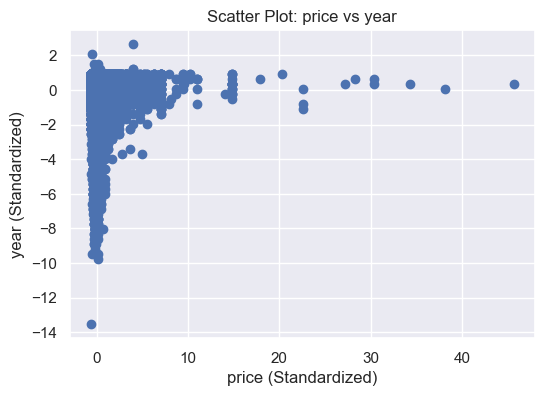

In [61]:
plt.figure(figsize=(6,4))
plt.scatter(df_standardized['price'], df_standardized['year'])
plt.xlabel("price (Standardized)")
plt.ylabel("year (Standardized)")
plt.title("Scatter Plot: price vs year")
plt.show()